<a href="https://colab.research.google.com/github/rko7/DA-Comparing-Classifiers/blob/main/Customer_Churn_Prediction_(Telco_Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2. Load dataset

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv("Telco-Customer-Churn.csv")
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Shape:", df.shape)
display(df.head())
df.info()

Shape: (7043, 20)


/tmp/ipython-input-3221299910.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


3. Exploratory Data Analysis (EDA)

/tmp/ipython-input-1875451720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


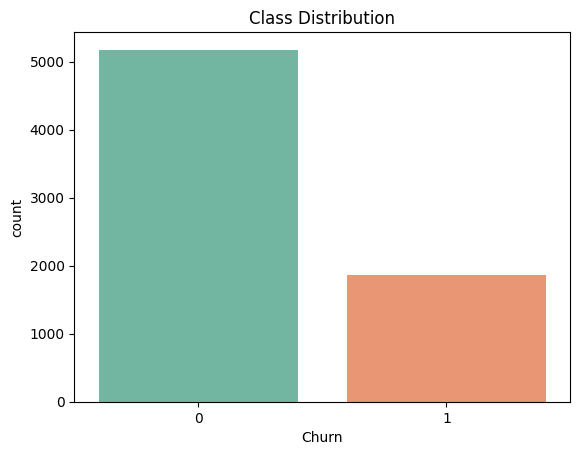

/tmp/ipython-input-1875451720.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set1')


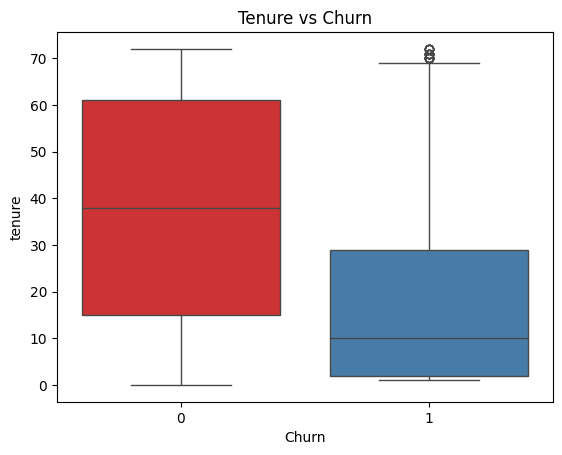

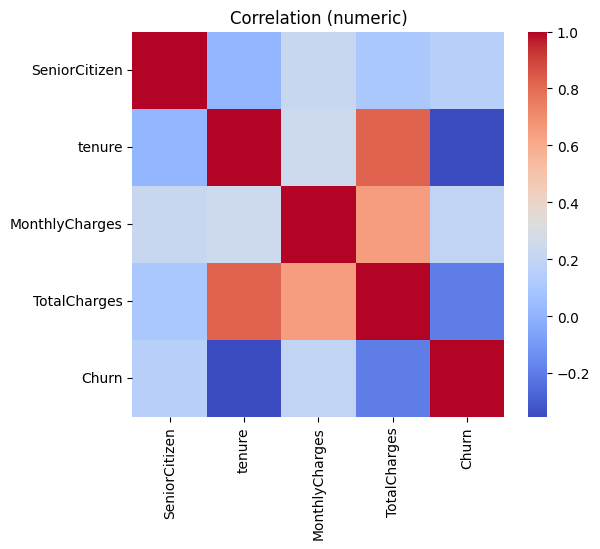

In [ ]:
# Check class distribution
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Class Distribution')
plt.show()

# Relationship between tenure and churn
plt.figure()
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set1')
plt.title('Tenure vs Churn')
plt.show()

# Correlation heatmap
num_df = df.select_dtypes(include=['int64', 'float64'])
if not num_df.empty:
    plt.figure(figsize=(6,5))
    sns.heatmap(num_df.corr(), cmap='coolwarm', annot=False)
    plt.title('Correlation (numeric)')
    plt.show()

4. Data Preprocessing

In [ ]:
# Encode categorical variables and split data
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Logistic Regression(LR) Model

Logistic Regression -> Accuracy: 0.807, AUC: 0.842
Confusion Matrix (LR):
[[925 110]
 [162 212]]


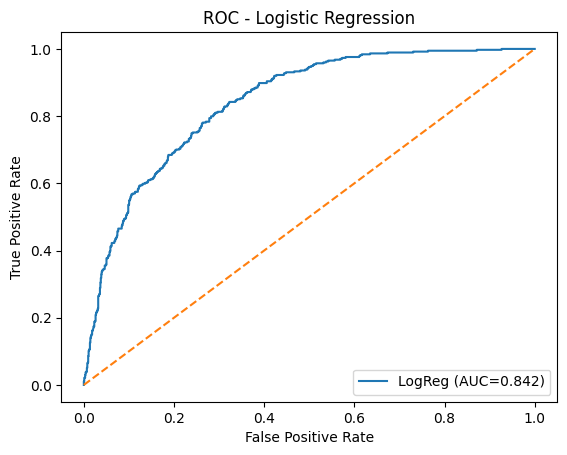

In [ ]:
# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predict and evaluate
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f'Logistic Regression -> Accuracy: {acc_lr:.3f}, AUC: {auc_lr:.3f}')
print('Confusion Matrix (LR):')
print(cm_lr)

# Plot ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={auc_lr:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

6. Neural Network Model (MLP)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network      -> Accuracy: 0.796, AUC: 0.839
Confusion Matrix (NN):
[[938  97]
 [191 183]]


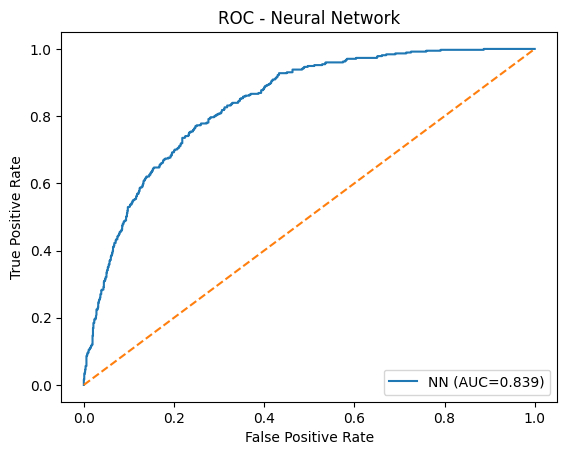

In [ ]:
# Build and train a simple Neural Network
nn = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam',
           loss='binary_crossentropy',
           metrics=['accuracy', keras.metrics.AUC(name='auc')])

history = nn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=32, verbose=0
)

# Evaluate Neural Network
eval_nn = nn.evaluate(X_test, y_test, verbose=0)
acc_nn = float(eval_nn[1])
auc_nn = float(eval_nn[2])

y_prob_nn = nn.predict(X_test, verbose=0).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
cm_nn = confusion_matrix(y_test, y_pred_nn)

print(f'Neural Network      -> Accuracy: {acc_nn:.3f}, AUC: {auc_nn:.3f}')
print('Confusion Matrix (NN):')
print(cm_nn)

# Plot ROC curve
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
plt.figure()
plt.plot(fpr_nn, tpr_nn, label=f'NN (AUC={auc_nn:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Neural Network')
plt.legend(loc='lower right')
plt.show()

7. Compare Models

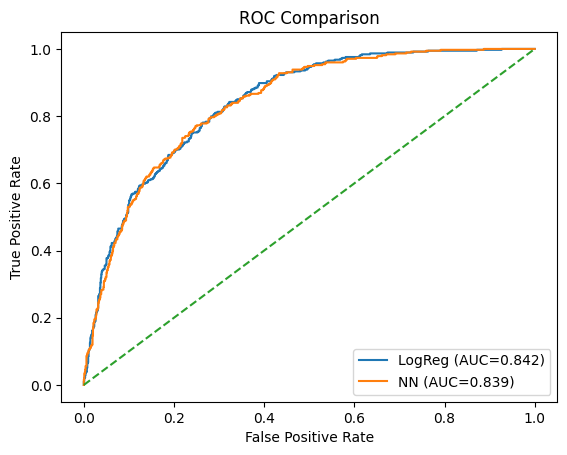

In [ ]:
# Compare ROC curves of both models
plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC={auc_lr:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'NN (AUC={auc_nn:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison')
plt.legend(loc='lower right')
plt.show()